# LP-Based Seam Carving

*Final project for IE 411: Optimization of Large-Scale Systems.*

Seam carving is a content-aware image-resizing technique: instead of cropping or
uniformly scaling an image, it removes the "seam" (a connected, one-pixel-wide path
from top to bottom) that carries the least visual information, one seam at a time.
This notebook formulates each seam-removal step as a **linear program** and solves
it with [Gurobi](https://www.gurobi.com/), rather than the classic dynamic-programming
approach seam carving is usually taught with.

## Problem formulation
<br>

### Graph construction

We represent the (grayscale) image as a directed acyclic graph $\mathcal{D} = (\mathcal{V}, \mathcal{E})$, where $\mathcal{V}$ is the set of nodes and $\mathcal{E}$ is the set of directed edges:

- **Nodes ($\mathcal{V}$).** Every pixel $(r, c)$, with row $r \in \{1, \dots, R\}$ and column $c \in \{1, \dots, C\}$, is a node ($R$ = image height, $C$ = image width, in pixels). We also add one dummy **sink** node $k$ that does not correspond to a real pixel — it exists only to give every seam a single common endpoint. 
<br>

- **Edges ($\mathcal{E}$).** Each pixel $(r, c)$ has a directed edge to each of its three "downward" neighbors that exist in the image:

  $$(r+1,\, c-1), \qquad (r+1,\, c), \qquad (r+1,\, c+1).$$
  
  This is what lets a seam bend slightly as it descends the image, rather than being forced into a straight vertical line. Additionally, every pixel in the last row $(R, c)$ has an edge to the sink $k$, so that "reaching the bottom of the image" and "reaching the sink" are the same thing.
  <br>
  
- **Edge costs.** Let $y(u)$ denote the grayscale intensity (0-255) of pixel $u$. Every edge $(u, v) \in \mathcal{E}$ has a cost.

  $$
  q(u, v) = \begin{cases} |y(u) - y(v)| & v \neq k \\ 0 & v = k \end{cases}
  $$
  
  Low-cost edges connect pixels with similar intensity, i.e. visually uniform regions. A cheap path through the image therefore threads through low-information content, which is exactly what we want to remove.

### Decision problem

A **seam** is a path in $\mathcal{D}$ from a fixed source pixel $(1, p)$ (top row, column $p$) to the sink $k$. The seam of least total cost is, by construction, the seam that removes the least visually important content. Since every edge cost is nonnegative, finding this seam is a **shortest-path problem**, which is a special case of *min-cost flow*, where we send exactly one unit of flow from the source to the sink at minimum total cost, and the edges the flow travels along trace out the shortest path.

### Primal formulation

**Decision variable:** For each edge $(u, v) \in \mathcal{E}$, $x_{uv} \geq 0$ is the amount of flow sent along that edge. In the optimal solution this comes out to $x_{uv} = 1$ for edges on the seam and $x_{uv} = 0$ for every other edge. We solve the continuous relaxation ($x_{uv} \geq 0$ rather than $x_{uv} \in \{0, 1\}$), and get an integral solution regardless because this particular constraint matrix is totally unimodular.

**Parameters:**
- $M \in \mathbb{R}^{|\mathcal{V}| \times |\mathcal{E}|}$: the **oriented incidence matrix** of $\mathcal{D}$, which means one row per node, one column per edge. Column $(u,v)$ has a $-1$ in row $u$ (flow leaving $u$), a $+1$ in row $v$ (flow entering $v$), and $0$ everywhere else.
- $q \in \mathbb{R}^{|\mathcal{E}|}$: the vector of edge costs defined above, one entry per edge.
- $d \in \mathbb{R}^{|\mathcal{V}|}$, the supply/demand vector, one entry per node:
  $$
  d_v = \begin{cases} -1 & \text{if } v \text{ is the source node, i.e. the pixel } (1, p) \\ +1 & \text{if } v \text{ is the sink node } k \\ 0 & \text{otherwise} \end{cases}
  $$
  ($-1$ means "one unit of flow originates here"; $+1$ means "one unit of flow must end up here.")

$$
\begin{aligned}
\min \quad & q^\top x \\
\text{s.t.} \quad & Mx = d \\
& x \geq 0
\end{aligned}
$$

The constraint $Mx = d$ enforces **flow conservation** at every node: for any node $v$ that isn't the source or sink, flow in must equal flow out (row $v$ of $Mx$ evaluates to $0$, matching $d_v = 0$). At the source, net *outflow* must be $1$; at the sink, net *inflow* must be $1$. Together these constraints force the optimal $x$ to trace out exactly one connected path from source to sink, which is the minimum-cost seam.

### Dual formulation

**Decision variable:** For each node $v \in \mathcal{V}$, $y_v \in \mathbb{R}$ (free, i.e. unrestricted in sign) is that node's **potential**, which means one dual variable per primal constraint (per node), since the primal had one flow-conservation constraint per node.

$$
\begin{aligned}
\max \quad & d^\top y \\
\text{s.t.} \quad & M^\top y \leq q \\
& y \ \text{free}
\end{aligned}
$$

By strong duality, the optimal primal and dual objective values coincide: $q^\top x^\star = d^\top y^\star$. We solve the dual each iteration purely as a correctness check on the primal solve, the seam itself only depends on $x^\star$.

### Complementary slackness

At an optimal primal-dual pair $(x^\star, y^\star)$, complementary slackness must hold:

$$
(y^\star)^\top (Mx^\star - d) = 0
\qquad \text{and} \qquad
(x^\star)^\top (q - M^\top y^\star) = 0
$$

The first says: wherever the dual variable $y_v^\star$ is nonzero, the primal constraint at node $v$ must be tight (which it always is here, since $Mx = d$ is an equality). The second says: for every edge $(u,v)$ actually used by the seam ($x_{uv}^\star > 0$), its dual "reduced cost" $q(u,v) - (y_v^\star - y_u^\star)$ must be exactly $0$. Both expressions are computed numerically at the end of every iteration below; they should evaluate to (numerically) zero if the solve is correct.

### Iterative seam removal

Removing one seam deletes one pixel from each row, shrinking the image by one column. We repeat the full solve (rebuild $\mathcal{D}$, solve primal, solve dual, check slackness) `NUM_ITERATIONS` times on the progressively narrower image, to remove that many seams in total.

### Helper functions

In [1]:
import time

import numpy as np
import networkx as nx
from PIL import Image
import gurobipy as gp
from gurobipy import GRB

In [2]:
def n(r, c, C):
    """Map a 1-indexed (row, col) pixel to a single 1-indexed node id."""
    return C * (r - 1) + c


def q_of(pixels, u, v, k):
    """Cost of edge u -> v: pixel-intensity difference, or 0 into the sink k."""
    if v == k:
        return 0
    return np.abs(pixels[u - 1] - pixels[v - 1])

### Configuration

In [3]:
# ---- Configuration: edit these for a different image / run ----
IMAGE_PATH = "tower.png"
SOURCE_COL = 50          # starting column (1-indexed) for the seam
NUM_ITERATIONS = 25      # number of seams (columns) to remove
OUTPUT_PATH = "final_image.png"

### Load the image

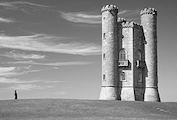

In [4]:
image = Image.open(IMAGE_PATH).convert("L")  # grayscale
R = image.height
C = image.width

pixels = list(image.getdata())  # flat pixel intensities, row-major
image

### Seam-carving loop

Each iteration: build the graph $\rightarrow$ solve the primal LP $\rightarrow$ remove the seam $\rightarrow$ solve the dual LP $\rightarrow$ check complementary slackness.

In [5]:
t0 = time.time()

for it in range(NUM_ITERATIONS):

    coords = [(r, c) for r in range(1, R + 1) for c in range(1, C + 1)]
    V = [n(r, c, C) for r, c in coords]

    k = R * C + 1  # dummy sink
    V.append(k)

    # each pixel can step down-left, straight down, or down-right
    adj = {
        n(r, c, C): [
            n(r2, c2, C)
            for (r2, c2) in [(r + 1, c - 1), (r + 1, c), (r + 1, c + 1)]
            if 1 <= r2 <= R and 1 <= c2 <= C
        ]
        for (r, c) in coords
    }
    # every pixel in the last row also connects to the sink
    for (r, c) in coords:
        if r == R:
            adj[n(r, c, C)].append(k)

    E = [(u, v) for u in V[:-1] for v in adj[u]]

    D = nx.DiGraph()
    D.add_nodes_from(V)
    D.add_edges_from(E)
    M = nx.incidence_matrix(D, oriented=True)

    q = np.array([q_of(pixels, u, v, k) for u, v in E])

    # ---------------- PRIMAL ----------------
    P = gp.Model("Primal Image Seaming")
    P.setParam("OutputFlag", 0)
    P.Params.LogToConsole = 0
    P.Params.Method = 0

    x = P.addMVar(D.number_of_edges(), vtype=GRB.CONTINUOUS, lb=0)
    d = np.zeros(D.number_of_nodes())
    d[SOURCE_COL - 1] = -1
    d[-1] = 1

    P.addConstr(M @ x == d)
    P.setObjective(q @ x, GRB.MINIMIZE)
    P.optimize()

    print("\nIteration: ", it + 1, "\nPrimal Objective: ", P.getObjective().getValue())

    # remove the seam pixels
    x_val = P.getAttr("X", P.getVars())
    seam = [E[i][0] - 1 for i in range(D.number_of_edges()) if x_val[i] >= 0.9]
    pixels = [v for i, v in enumerate(pixels) if i not in seam]
    C -= 1

    # ---------------- DUAL ----------------
    Q = gp.Model("Dual Image Seaming")
    Q.Params.LogToConsole = 0
    Q.Params.Method = 0

    y = Q.addMVar(shape=D.number_of_nodes(), vtype=GRB.CONTINUOUS, lb=0, name="y")
    Q.addConstr(q >= M.transpose() @ y)
    Q.setObjective(d @ y, GRB.MAXIMIZE)
    Q.optimize()

    print("Dual objective: ", Q.getObjective().getValue())
    y_val = Q.getAttr("X", Q.getVars())

    # Complementary slackness:   y . (M x - d) = 0   and   x . (q - M^T y) = 0
    print("Complementary slackness: ", (M @ x_val - d) @ y_val)
    print("Complementary slackness: ", (q - M.transpose() @ y_val) @ x_val)

t1 = time.time()

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-13

Iteration:  1 
Primal Objective:  327.0
Set parameter LogToConsole to value 0
Dual objective:  327.0
Complementary slackness:  0.0
Complementary slackness:  0.0

Iteration:  2 
Primal Objective:  357.0
Set parameter LogToConsole to value 0
Dual objective:  357.0
Complementary slackness:  0.0
Complementary slackness:  0.0

Iteration:  3 
Primal Objective:  390.0
Set parameter LogToConsole to value 0
Dual objective:  390.0
Complementary slackness:  0.0
Complementary slackness:  0.0

Iteration:  4 
Primal Objective:  395.0
Set parameter LogToConsole to value 0
Dual objective:  395.0
Complementary slackness:  0.0
Complementary slackness:  0.0

Iteration:  5 
Primal Objective:  402.0
Set parameter LogToConsole to value 0
Dual objective:  402.0
Complementary slackness:  0.0
Complementary slackness:  0.0

Iteration:  6 
Primal Objective:  410.0
Set parameter LogToConsole to value 0
Dual objective:  410

### Save and display the result

elapsed  315.8656303882599


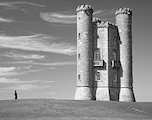

In [6]:
out = np.reshape(pixels, (R, C)).astype("uint8")
final_image = Image.fromarray(out)
final_image.save(OUTPUT_PATH)

print("elapsed ", t1 - t0)
final_image